# 03 — Business Deep Dive

In notebook 02 we described *what* the data looks like. This notebook asks *why*,
and stress-tests the headline findings before turning them into business advice.

Each section follows the same investigative pattern:

1. **Hypothesis** — a clear, falsifiable claim about what is driving a result.
2. **Evidence** — the metrics and visualization used to test that claim.
3. **Conclusion** — what the evidence supports, stated in business terms.

The goal is not to confirm the obvious, but to separate real drivers from
surface-level correlations — the difference between "Electronics earns the most"
and "Electronics earns the most *because* of price, not volume."

In [1]:
import sys
sys.path.append('..')
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from src.plots import *
from src.analysis import *

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
pd.set_option('display.max_columns', None)

In [2]:
df = pd.read_csv('../data/processed/retail_sales_cleaned.csv', parse_dates = ['order_date'])
fig_path = "../reports/figures/"

## Business Question 1 — Why does Electronics dominate revenue?

Initial analysis showed Electronics contributes disproportionately to total
revenue. Three competing explanations exist:

- Electronics products are simply more expensive (price driver).
- Customers buy more Electronics items per order (basket driver).
- Electronics receives more orders (demand driver).

**Hypothesis:** dominance is primarily a *price* effect, reinforced by strong
order volume — not by larger baskets per order.

**Evidence:** per-category profile of average unit price, average quantity,
and order count shown as a normalized category-vs-metric
heatmap so each category's "signature" is visible at a glance.

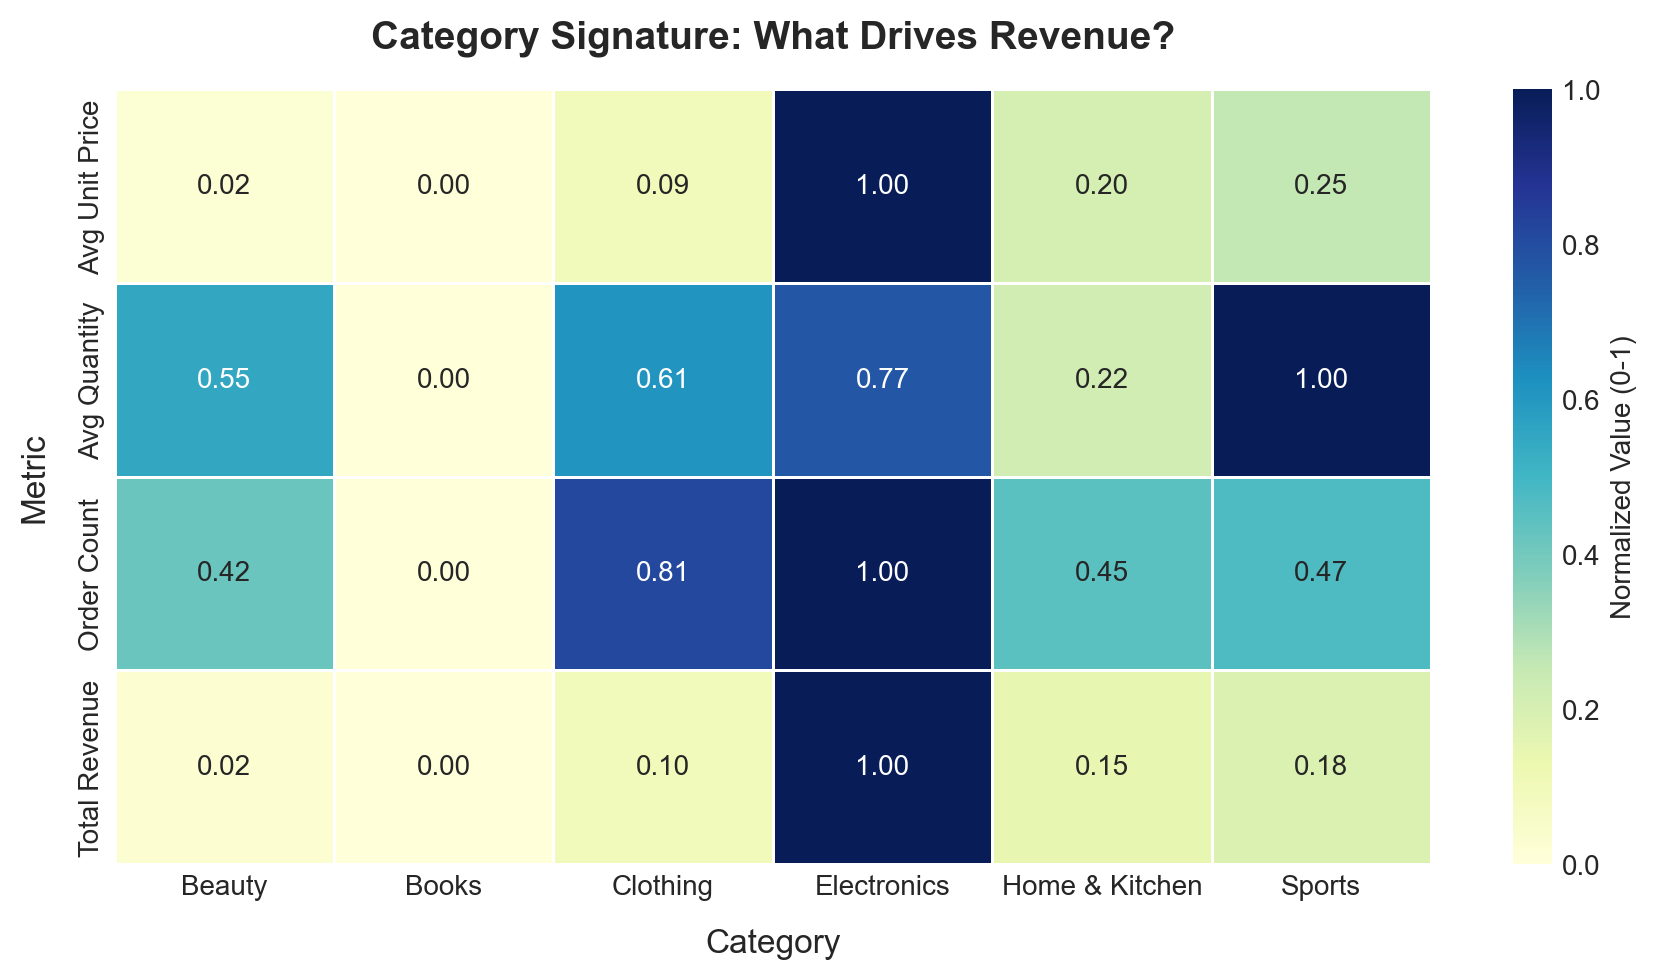

In [3]:
norm_heatmap_data = get_category_signature_data(df)

output_path = fig_path + 'q1_category_signature_heatmap.png'
output_path = None if Path(output_path).exists() else output_path

plot_category_signature_heatmap(norm_heatmap_data, output_path)

**Conclusion:** Electronics leads every category in average unit price while
keeping comparable quantity per order, and it also attracts the most orders. Its
revenue is therefore explained by *high transaction value combined with strong
demand*, not by larger baskets. 

---

## Business Question 2 — Is West really the best-performing region?

EDA identified West as the highest-revenue region. However, high revenue may result
from either higher spending per transaction or simply serving more customers.

**Hypothesis:** West's revenue leadership is driven by customer volume rather than
larger transactions.

**Evidence:** Decompose regional performance into three components:
customer count, orders per customer, and average order value.

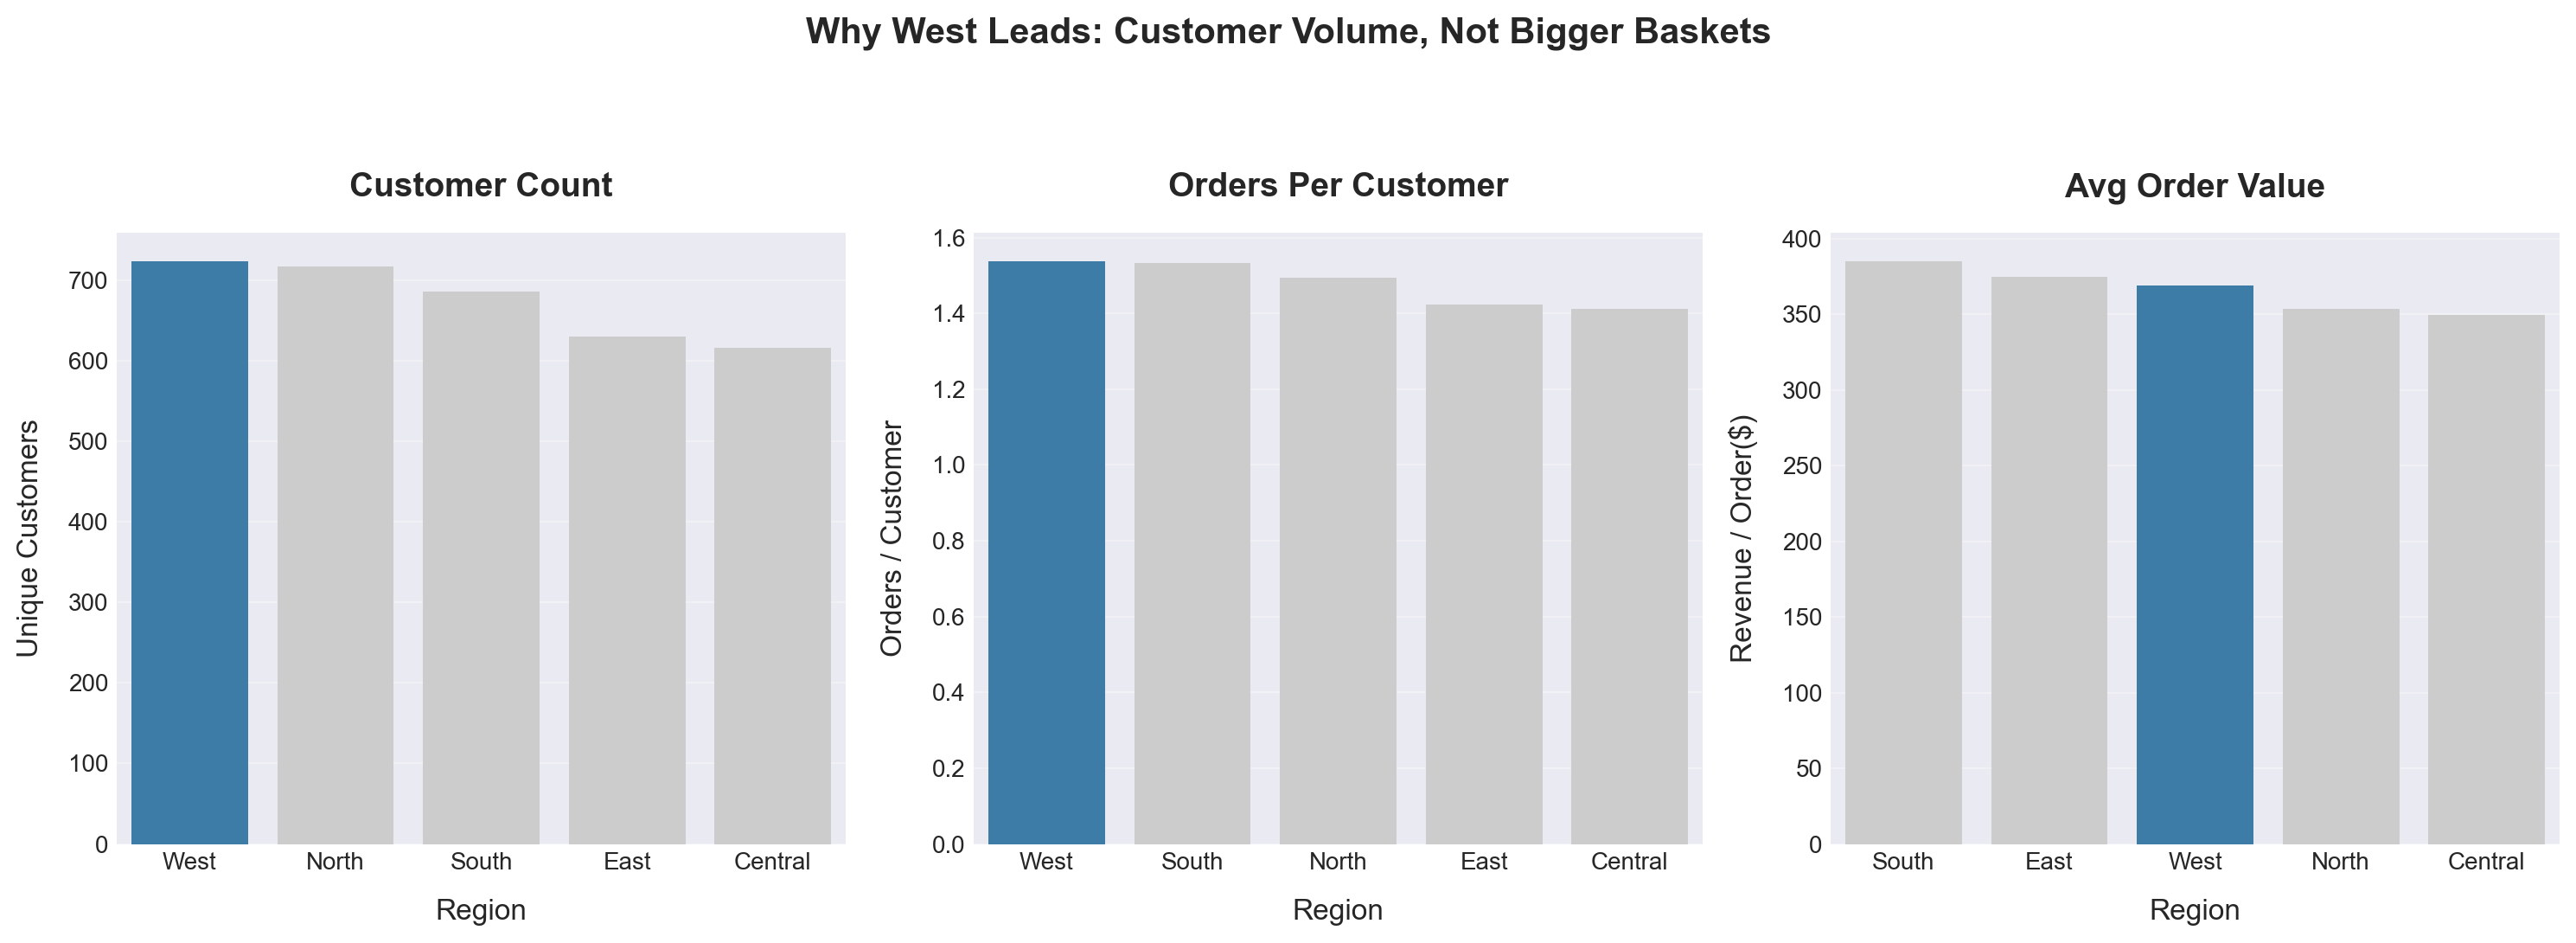

In [4]:
regional_data = get_regional_decomposition_data(df)

output_path = fig_path + 'q2_region_decomposition.png'
output_path = None if Path(output_path).exists() else output_path

plot_regional_decomposition(regional_data, output_path)

**Conclusion:** West’s revenue leadership is primarily driven by its *larger customer base*, while purchase frequency is only slightly higher than in other regions. Average order value remains comparable—and is even exceeded by the South—indicating that West succeeds by attracting more customers rather than generating higher-value transactions. Future revenue growth in lower-performing regions should therefore prioritize *customer acquisition and retention* over increasing basket size.

--- 

## Business Question 3 — Do discounts improve customer satisfaction?

Aggregate analysis suggested a positive relationship between discount level and
customer rating. However, an overall trend may simply reflect differences in
customer or product composition rather than a genuine pricing effect.

**Hypothesis:** the positive discount-rating relationship is robust and holds
within segments, not just in aggregate.

**Evidence:** average rating by discount bucket, plotted as three lines —
Overall, Electronics, and West — to check whether the trend survives
segmentation.

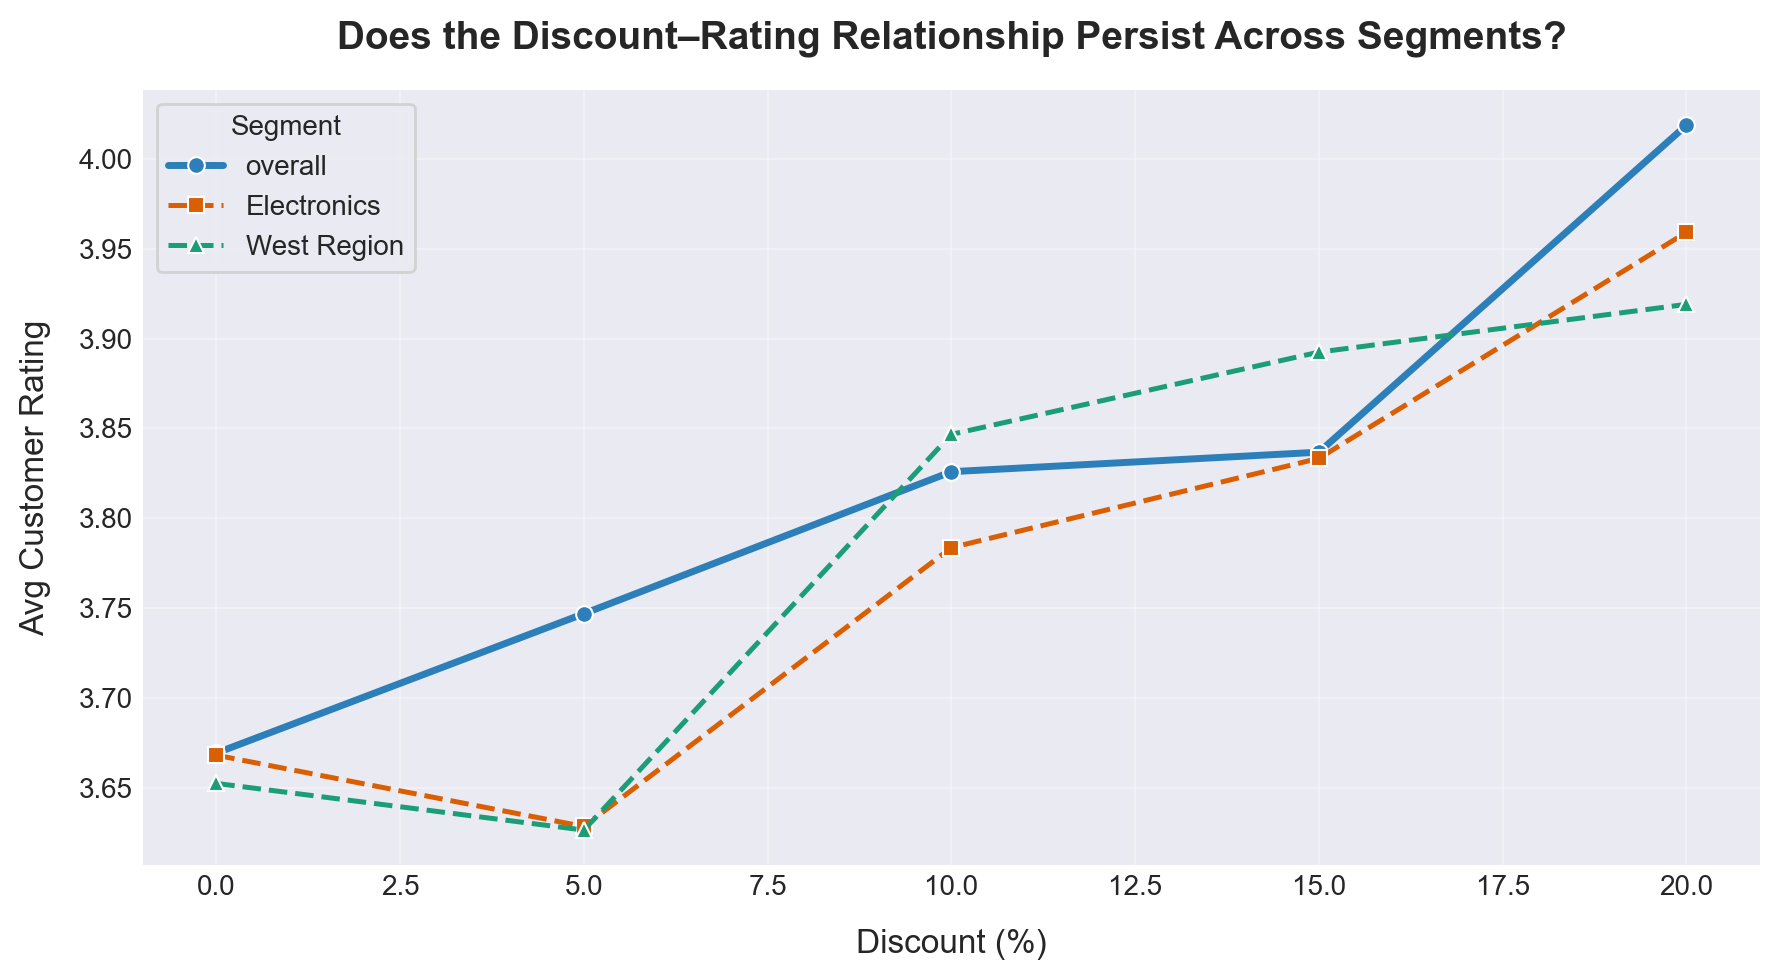

In [5]:
discount_vs_rating_data = get_discount_vs_rating_data(df)

output_path = fig_path + 'q3_discount_vs_rating.png'
output_path = None if Path(output_path).exists() else output_path

plot_discount_vs_rating_segments(discount_vs_rating_data, output_path)

**Conclusion:** The positive relationship between discount level and customer
ratings persists across the overall dataset as well as within the Electronics
category and the West region. Although the increase is not perfectly monotonic,
customers consistently report higher average ratings at larger discount levels.
This suggests the observed association is robust across key business segments
rather than being driven by the overall data composition.

--- 

## Business Question 4 — Is company revenue safely diversified, or highly concentrated?

While we know Electronics is our strongest category, we need to determine if our overall business revenue is healthily distributed across our catalog, or if we are dangerously dependent on a few flagship items.

**Hypothesis:** Total company revenue is highly concentrated in a handful of top-selling products (primarily Electronics), creating significant product dependency risk.

**Evidence:** Rank all products across the entire store by total revenue generated. Calculate the cumulative revenue share of the Top 5 products relative to the entire company's earnings, and analyze the category makeup of those top performers.

The top 5 products account for 68.6 of total company revenue.


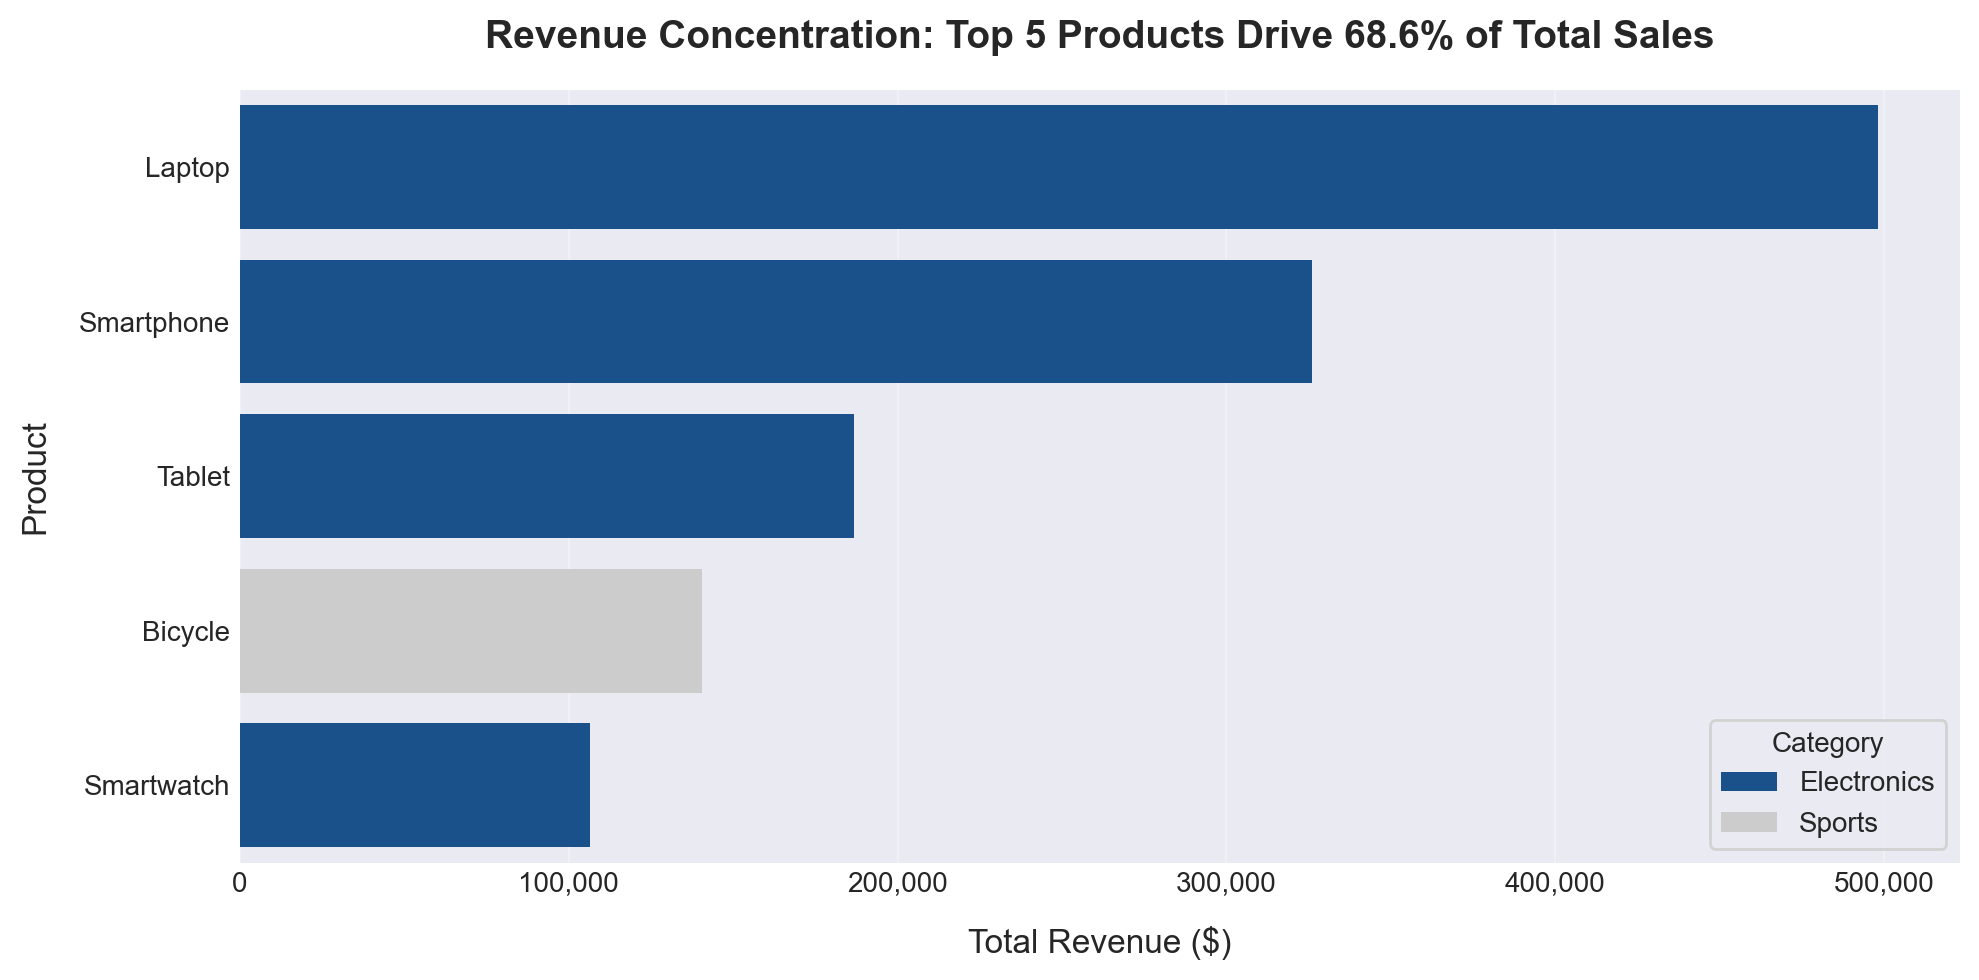

In [6]:
product_revenue, top_5_product_share = get_product_concentration_data(df)
print(f"The top 5 products account for {top_5_product_share:.1f} of total company revenue.")

output_path = fig_path + 'q4_product_concentration.png'
output_path = None if Path(output_path).exists() else output_path

plot_product_concentration(product_revenue, top_5_product_share, output_path)

**Conclusion:** Revenue concentration poses a significant structural risk to the business, with the top 5 highest-grossing products accounting for a massive **68.6%** of total company sales. This vulnerability is heavily anchored within the Electronics category, which claims four of the top five ranking positions. Our entire store's financial performance relies heavily on three absolute flagship items: Laptop, Smartphone, and Tablet. Protecting these key product lines and retaining their customer base must remain an absolute operational priority.

---

## Business Question 5 — Who drives company revenue?

Individual customer IDs are useful operationally, but business strategy is driven
by customer segments rather than specific people. We therefore classify customers
by lifetime spending and compare their share of the customer base with their share
of total revenue.

**Hypothesis:** A relatively small group of high-value customers contributes a
disproportionately large share of company revenue.

**Evidence:** Compare customer composition with revenue composition using two
side-by-side pie charts: one showing the percentage of customers in each segment
(VIP, Regular, Standard), and the other showing the percentage of total revenue
generated by each segment.

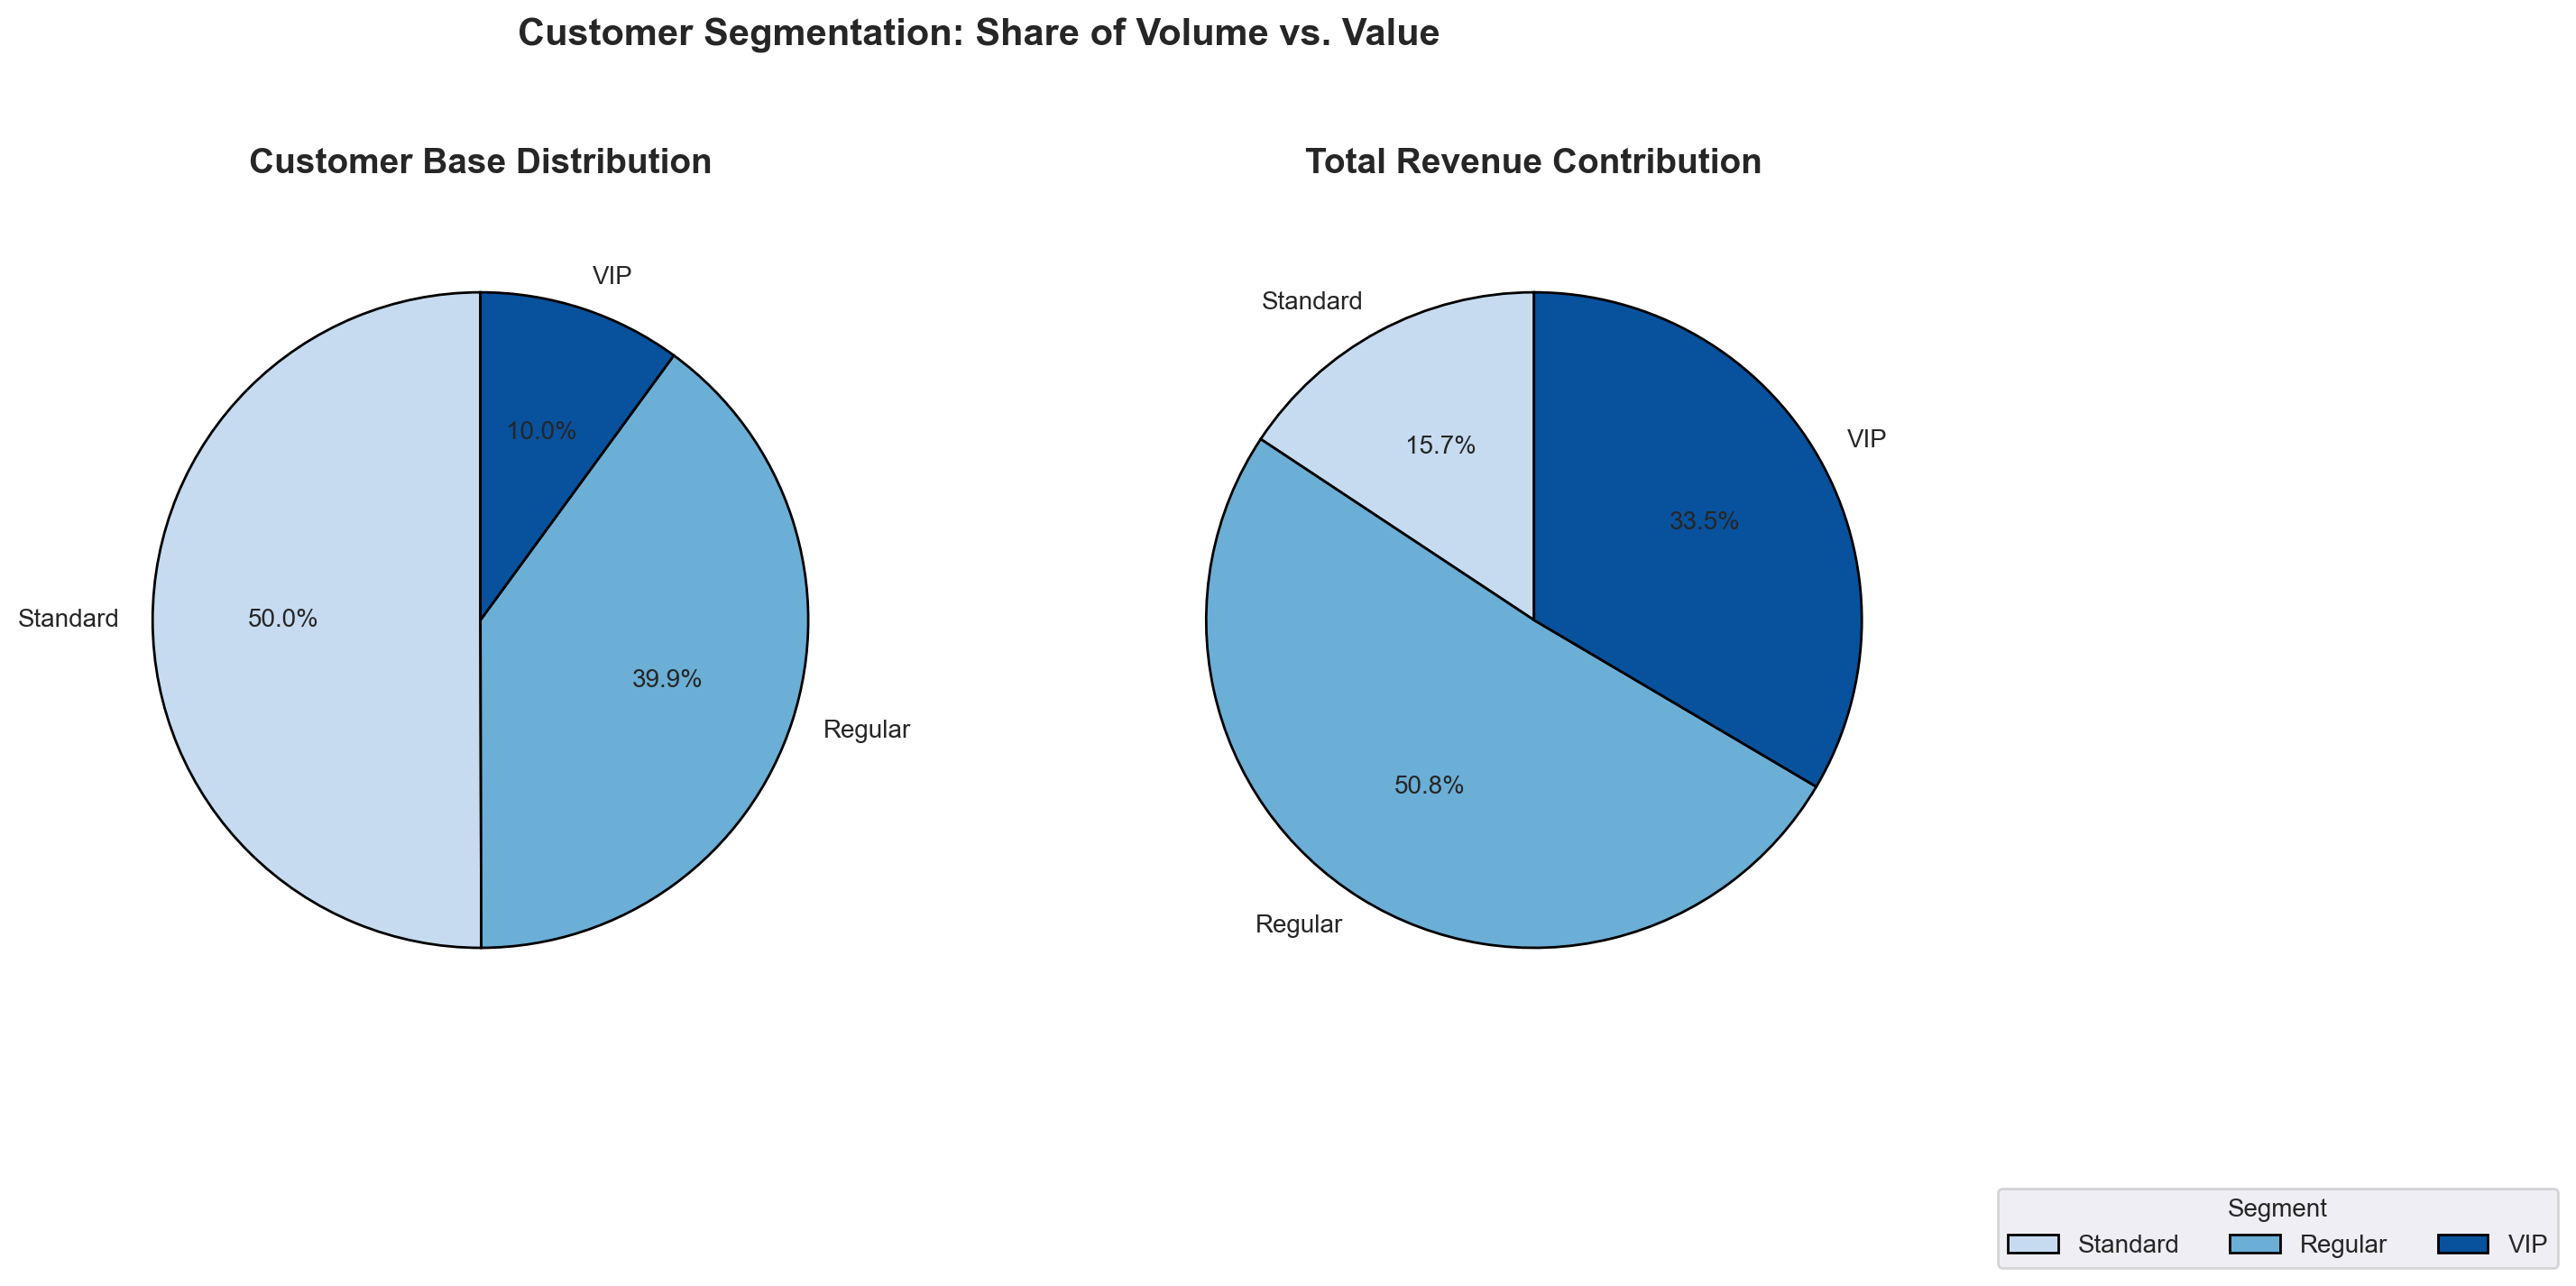

In [7]:
customer_class_data = get_customer_segmentation_data(df)

output_path = fig_path + 'q5_customer_vs_revenue_share.png'
output_path = None if Path(output_path).exists() else output_path

plot_customer_segmentation(customer_class_data, output_path)

**Conclusion:** Although VIP customers represent only the top 10% of the customer
base, they contribute approximately one-third of total revenue. In contrast,
half of all customers generate less than one-sixth of revenue. These findings
highlight customer retention among high-value customers as a key business
priority alongside customer acquisition.

--- 

## Business Question 6 — What caused the June 2024 sales rebound?

Monthly revenue increased sharply in June 2024. Before recommending any
business action, we need to understand whether the recovery reflects broad
improvement across the business or is driven by a single product category.

**Hypothesis:** The June rebound is primarily driven by Electronics rather than
balanced growth across all categories.

**Evidence:** Compare category-level monthly revenue around the recovery period
(April–June 2024) to identify which categories contributed most to the increase.

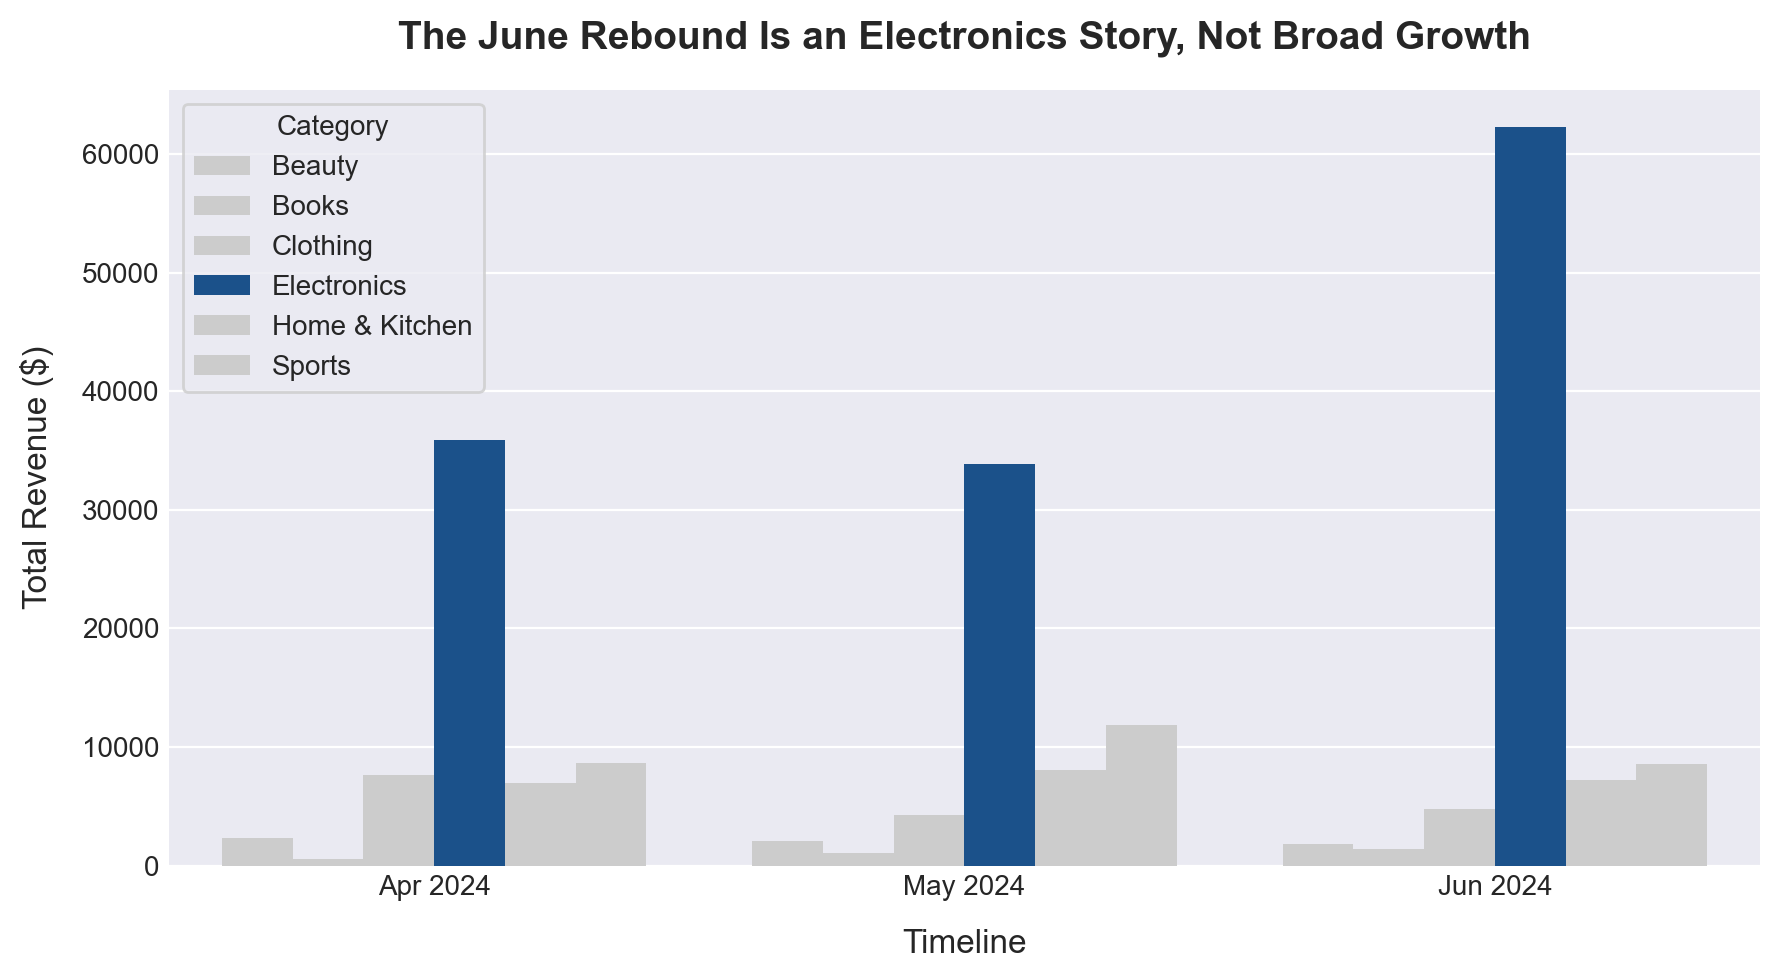

In [8]:
rebound_metrics = get_june_rebound_data(df)

output_path = fig_path + 'q6_june_rebound_decomposition.png'
output_path = None if Path(output_path).exists() else output_path

plot_june_rebound_decomposition(rebound_metrics, output_path)

**Conclusion:** June's sales recovery was driven primarily by Electronics. While
most categories showed only modest month-to-month fluctuations, Electronics
experienced a sharp increase in both order volume (31 → 55 orders) and revenue
($33.8k → $62.3k). The recovery therefore reflects category-specific demand
rather than a broad improvement across the business.